Kelvin - Helmholtz code, aiming to replicate "A Validated Nonlinear Kelvin-Helmholtz Benchmark for Numerical
Hydrodynamics" by Lecoanet et al 2021

### 1. Imports

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from typing import NamedTuple
from jaxtyping import Array

# Import core MHX structures
from mhx.grids import CartesianGrid
from mhx.config.schema import MeshConfig
from mhx.state import ReducedMHDParams, ReducedMHDState
from mhx.runtime import configure_jax
from mhx.time_integrators import evolve_rk4

from mhx.equations.reduced_mhd import reduced_mhd_rhs, stream_function, poisson_bracket
from mhx.numerics.spectral import laplacian

configure_jax(enable_x64=True)
print(f"JAX running on: {jax.devices()}")

ERROR:2026-06-10 10:33:38,738:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ohfact/miniconda3/envs/mhx_env/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/ohfact/miniconda3/envs/mhx_env/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/ohfact/miniconda3/envs/mhx_env/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


JAX running on: [CpuDevice(id=0)]


### 2. Pytree wrapper
Since NamedTuple is interpreted by JAX natively as a PyTree, we can define a new state class which holds
1. 'mhd': The standard 'ReducedMHDState' (containing $\psi$ and $\omega$).
2. `c`: Our custom 2D Array for the dye concentration.

When we pass this into `evolve_rk4`, JAX will automatically know how to traverse, differentiate, and update this entire nested structure!

In [2]:
class KHDyeState(NamedTuple):
    """Custom PyTree state combining standard MHD fields with a passive dye scalar."""
    mhd: ReducedMHDState
    c: Array

### 3. Custom Right-Hand Side (RHS) Equation
Now we define the physics. We want the core `mhx` solver to handle the complex fluid/magnetic dynamics, but we need to manually advect and diffuse our custom dye field.

The advection-diffusion equation for a passive scalar in streamfunction formulation is:
$\frac{\partial c}{\partial t} = -[\phi, c] + \nu_{dye} \nabla^2 c$

We unpack the state, let `reduced_mhd_rhs` update the core fluid, and then update the dye ourselves.

In [3]:
def kh_dye_rhs(state: KHDyeState, params: ReducedMHDParams, grid: CartesianGrid) -> KHDyeState:
    """Calculates the time derivative for both the core MHD state and the custom dye field."""

    # 1. Delegate core fluid/magnetic evolution to the unmodified MHX solver
    dmhd = reduced_mhd_rhs(state.mhd, params, lengths=grid.lengths)

    # 2. Extract fields needed to calculate dye advection
    omega = state.mhd.omega
    c = state.c
    lengths = grid.lengths

    # 3. Calculate the streamfunction (∇²φ = ω)
    phi = stream_function(omega, lengths=lengths)

    # 4. Calculate dye advection and diffusion
    # Note: In the paper, nu_dye = kinematic viscosity (nu), so we reuse params.viscosity
    lap_c = laplacian(c, lengths=lengths)
    advection = -poisson_bracket(phi, c, lengths=lengths)
    diffusion = params.viscosity * lap_c

    dc = advection + diffusion

    # Return the bundled rates of change
    return KHDyeState(mhd=dmhd, c=dc)

### 4. Initial Conditions
We initialize the exact conditions specified in the benchmark paper.

In [4]:
def lecoanet_kh_initial_state(grid: CartesianGrid) -> KHDyeState:
    """Initializes the smooth double shear layer and dye concentration."""
    x, y = grid.mesh()
    Lx, Ly = grid.lengths

    y1, y2 = 0.5, 1.5
    a = 0.05         # Shear layer width
    sigma = 0.2      # Perturbation envelope width
    A = 0.01         # Perturbation amplitude
    u_flow = 1.0     # Background flow velocity
    kx = 2.0 * jnp.pi / Lx

    # Velocity Gradients
    sech1 = 1.0 / jnp.cosh((y - y1) / a)
    sech2 = 1.0 / jnp.cosh((y - y2) / a)
    dy_ux = (u_flow / a) * (sech1**2 - sech2**2)

    env1 = jnp.exp(-((y - y1)**2) / (sigma**2))
    env2 = jnp.exp(-((y - y2)**2) / (sigma**2))
    dx_uy = A * kx * jnp.cos(kx * x) * (env1 + env2)

    # Core MHD State (Hydrodynamic only, psi = 0)
    omega = dx_uy - dy_ux
    psi = jnp.zeros_like(x)
    mhd_state = ReducedMHDState(psi=psi, omega=omega)

    # Custom Dye Concentration (Equation 8e)
    c = 0.5 * (jnp.tanh((y - y2) / a) - jnp.tanh((y - y1) / a) + 2.0)

    return KHDyeState(mhd=mhd_state, c=c)

### 5. Diagnostics and Plotting
To verify our results against Figures 1, 3, and 5 of the paper, we will calculate the volume-integrated entropy ($S \equiv \int -c \ln c \, dV$) and render the `RdBu_r` colormap.

In [5]:
def calculate_entropy(c_field: np.ndarray, grid: CartesianGrid) -> float:
    """Calculates volume-integrated dye entropy."""
    c_safe = np.clip(c_field, 1e-12, 1.0)
    entropy_density = -c_safe * np.log(c_safe)
    area = grid.lengths[0] * grid.lengths[1]
    return float(np.mean(entropy_density) * area)

def plot_dye_inline(c_np: np.ndarray, grid: CartesianGrid, time: float):
    """Renders the dye field directly in the Jupyter Notebook."""
    plt.figure(figsize=(4, 6))
    im = plt.imshow(
        c_np.T,
        origin="lower",
        cmap="RdBu_r",
        vmin=0.0,
        vmax=1.0,
        extent=(0.0, grid.lengths[0], 0.0, grid.lengths[1])
    )
    plt.title(f"KH Dye (t={time:.2f})")
    plt.xlabel("x / Lx")
    plt.ylabel("z / Lz")
    plt.colorbar(im, label="Concentration (c)")
    plt.show()

### 6. Re 10^6 run

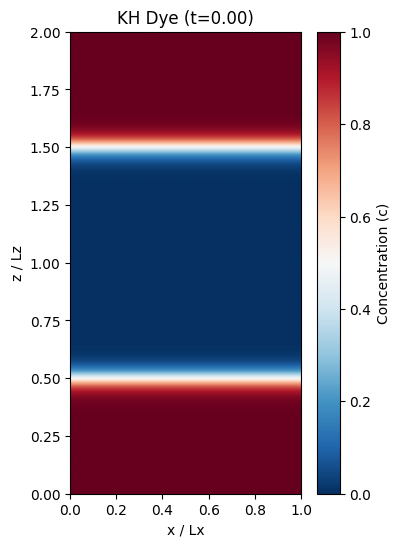

Running 10000 steps in 50 chunks...
Chunk 1/50 complete. (t=0.200) | S=0.0823
Chunk 2/50 complete. (t=0.400) | S=0.0823
Chunk 3/50 complete. (t=0.600) | S=0.0823
Chunk 4/50 complete. (t=0.800) | S=0.0823
Chunk 5/50 complete. (t=1.000) | S=0.0823


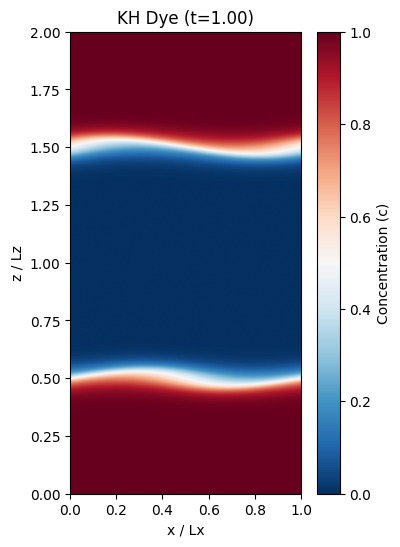

Chunk 6/50 complete. (t=1.200) | S=0.0823
Chunk 7/50 complete. (t=1.400) | S=0.0823
Chunk 8/50 complete. (t=1.600) | S=0.0823
Chunk 9/50 complete. (t=1.800) | S=0.0824
Chunk 10/50 complete. (t=2.000) | S=0.0826


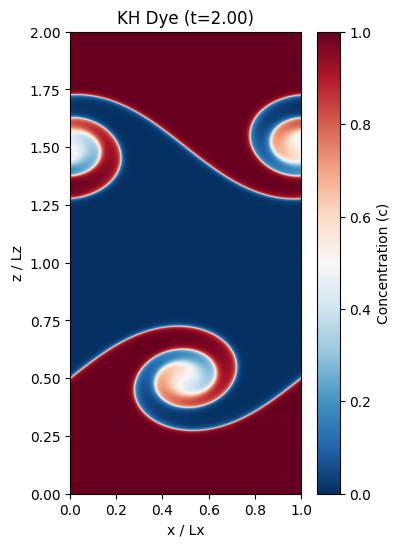

Chunk 11/50 complete. (t=2.200) | S=0.0831
Chunk 12/50 complete. (t=2.400) | S=0.0835
Chunk 13/50 complete. (t=2.600) | S=0.0844
Chunk 14/50 complete. (t=2.800) | S=0.0858
Chunk 15/50 complete. (t=3.000) | S=0.0886


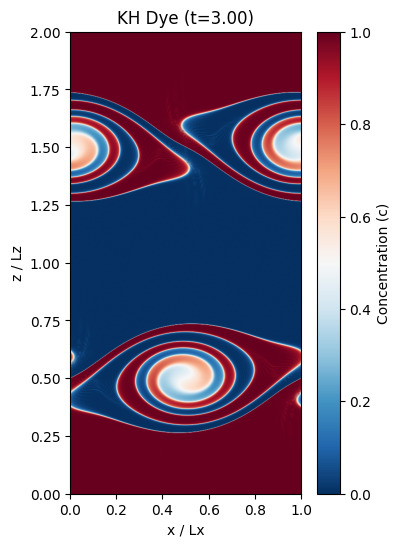

Chunk 16/50 complete. (t=3.200) | S=0.0927
Chunk 17/50 complete. (t=3.400) | S=0.0947
Chunk 18/50 complete. (t=3.600) | S=0.0986
Chunk 19/50 complete. (t=3.800) | S=0.1028
Chunk 20/50 complete. (t=4.000) | S=0.1056


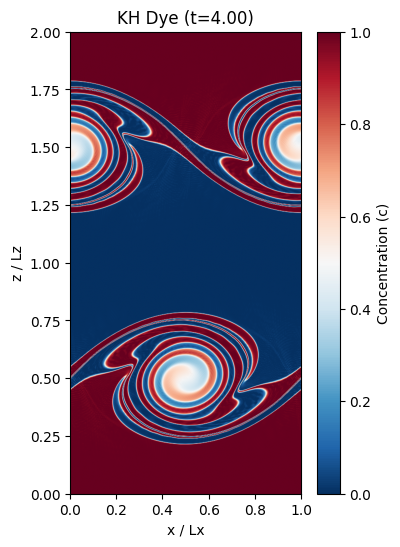

Chunk 21/50 complete. (t=4.200) | S=0.1113
Chunk 22/50 complete. (t=4.400) | S=0.1158
Chunk 23/50 complete. (t=4.600) | S=0.1208
Chunk 24/50 complete. (t=4.800) | S=0.1301
Chunk 25/50 complete. (t=5.000) | S=0.1404


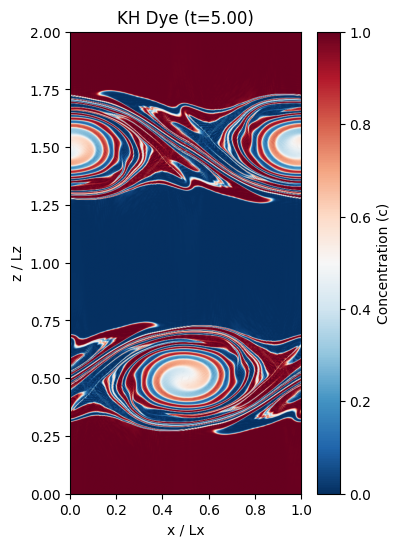

Chunk 26/50 complete. (t=5.200) | S=0.1482
Chunk 27/50 complete. (t=5.400) | S=0.1578
Chunk 28/50 complete. (t=5.600) | S=0.1702
Chunk 29/50 complete. (t=5.800) | S=0.1762
Chunk 30/50 complete. (t=6.000) | S=0.1836


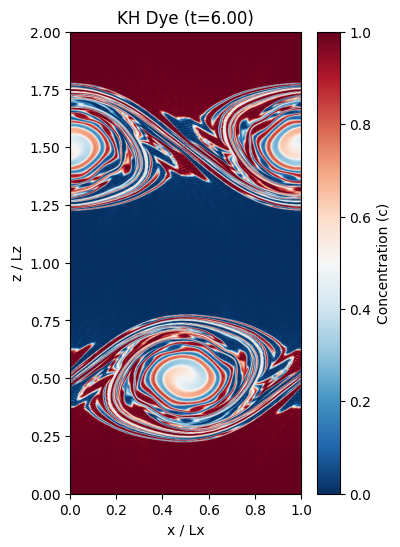

Chunk 31/50 complete. (t=6.200) | S=0.1900
Chunk 32/50 complete. (t=6.400) | S=0.1985
Chunk 33/50 complete. (t=6.600) | S=0.2089
Chunk 34/50 complete. (t=6.800) | S=0.2145
Chunk 35/50 complete. (t=7.000) | S=0.2231


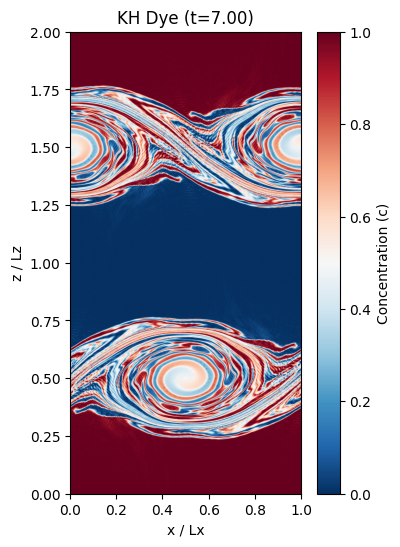

Chunk 36/50 complete. (t=7.200) | S=0.2294
Chunk 37/50 complete. (t=7.400) | S=0.2351
Chunk 38/50 complete. (t=7.600) | S=0.2396
Chunk 39/50 complete. (t=7.800) | S=0.2439
Chunk 40/50 complete. (t=8.000) | S=0.2494


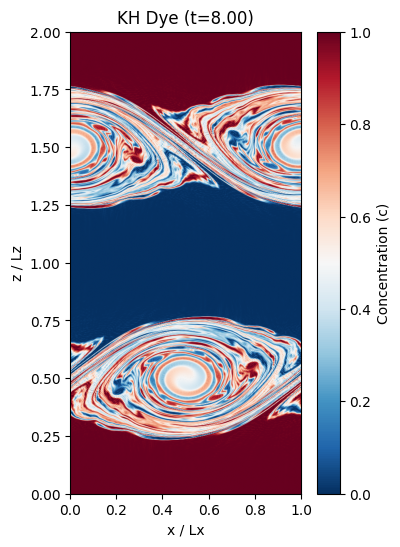

Chunk 41/50 complete. (t=8.200) | S=0.2546
Chunk 42/50 complete. (t=8.400) | S=0.2577
Chunk 43/50 complete. (t=8.600) | S=0.2614
Chunk 44/50 complete. (t=8.800) | S=0.2658
Chunk 45/50 complete. (t=9.000) | S=0.2695


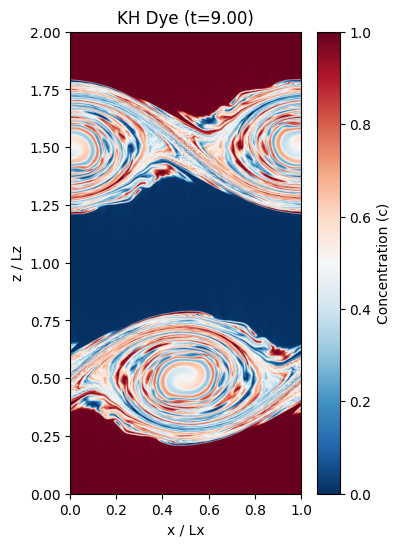

Chunk 46/50 complete. (t=9.200) | S=0.2712
Chunk 47/50 complete. (t=9.400) | S=0.2734
Chunk 48/50 complete. (t=9.600) | S=0.2755
Chunk 49/50 complete. (t=9.800) | S=0.2772
Chunk 50/50 complete. (t=10.000) | S=0.2792


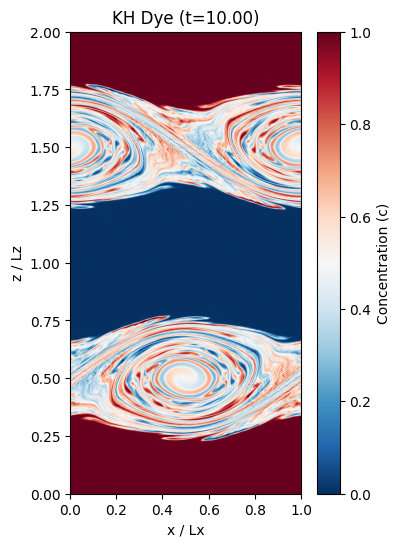

Exporting MHX entropy data to CSV...


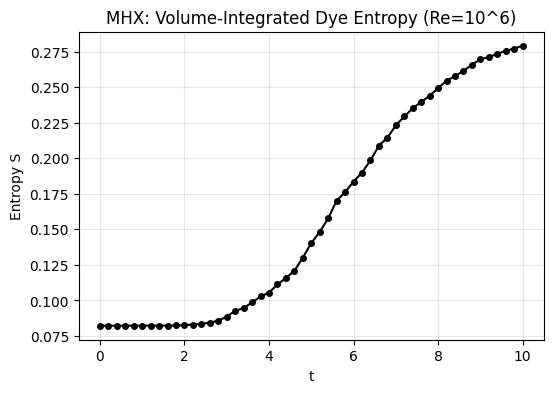

In [7]:
# --- Simulation Parameters (Re = 10^6) ---
NX, NY = 512, 1024
NU = 1e-6
DT = 1e-3       
T_END = 10.0         
SAVE_EVERY = 200  

grid = CartesianGrid.from_mesh_config(
    MeshConfig(shape=(NX, NY), lower=(0.0, 0.0), upper=(1.0, 2.0))
)

# Initialize standard physics parameters
params = ReducedMHDParams(resistivity=0.0, viscosity=NU)

# Wrap our custom RHS so it only requires 'state' (as expected by evolve_rk4)
def rhs_wrapper(state: KHDyeState) -> KHDyeState:
    return kh_dye_rhs(state, params, grid)

# Initialize State
current_state = lecoanet_kh_initial_state(grid)

# Plot t=0
c_init = np.asarray(current_state.c)
plot_dye_inline(c_init, grid, 0.0)

times_list = [0.0]
entropies = [calculate_entropy(c_init, grid)]

total_steps = int(T_END / DT)
num_chunks = total_steps // SAVE_EVERY

print(f"Running {total_steps} steps in {num_chunks} chunks...")

for chunk in range(num_chunks):
    trajectory = evolve_rk4(
        current_state,
        rhs_wrapper,
        dt=DT,
        steps=SAVE_EVERY,
        save_every=SAVE_EVERY,
    )

    trajectory.times.block_until_ready()
    current_state = jax.tree_util.tree_map(lambda x: x[-1], trajectory.states)

    t = (chunk + 1) * SAVE_EVERY * DT
    c_field = np.asarray(current_state.c)

    # Track Diagnostics
    S = calculate_entropy(c_field, grid)
    times_list.append(t)
    entropies.append(S)

    print(f"Chunk {chunk + 1}/{num_chunks} complete. (t={t:.3f}) | S={S:.4f}")

    if t >= 1.0 and abs(t % 1.0) < (DT * SAVE_EVERY * 0.5):
        plot_dye_inline(c_field, grid, t)


# === NEW: EXPORT DATA FOR DEDALUS COMPARISON ===
import csv

# Save the time and entropy arrays to a CSV file
print("Exporting MHX entropy data to CSV...")
csv_path = "mhx_re1e6_entropy.csv"
with open(csv_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["time", "entropy"])
    for time_val, ent_val in zip(times_list, entropies):
        writer.writerow([time_val, ent_val])

# --- Final Entropy Plot ---
plt.figure(figsize=(6, 4))
plt.plot(times_list, entropies, marker='o', markersize=4, color='k')
plt.xlabel("t")
plt.ylabel("Entropy S")
plt.title(f"MHX: Volume-Integrated Dye Entropy (Re=10^6)")
plt.grid(True, alpha=0.3)
plt.show()